# Using Web Map API through the map widget
Notebook demonstrating various capabilities of the new web map API

In [1]:
from arcgis.gis import *
from arcgis.mapping import WebMap
from arcgis.raster import apply
from arcgis.features import FeatureLayer
from arcgis.geocoding import geocode
from arcgis.features import FeatureSet, FeatureCollection

In [2]:
gis = GIS("https://www.arcgis.com","arcgis_python", "amazing_arcgis_123")
anon_gis= GIS(set_active=False)

## Add different layer types
General data source - [http://data-georgiagio.opendata.arcgis.com/datasets](http://data-georgiagio.opendata.arcgis.com/datasets)
### Feature layer item

<Item title:"Census Blocks 2010 (with 2017 and 2022 Data)" type:Feature Layer Collection owner:JohnsCreekGA>
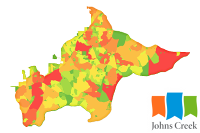

In [3]:
flc_item = gis.content.get('8d29d4a521f34ebba40dd918ac8322c3')
flc_item

In [4]:
flc_item.layers

[<FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">]

In [19]:
map1 = gis.map("Duluth, GA", zoomlevel=11)
map1

In [20]:
map1.draw('freehandpolyline')

In [21]:
map1.draw([34.0029, -84.1446])

In [8]:
map1._js_layer_list

''

In [9]:
map1.layers

[]

In [22]:
map1.add_layer(flc_item.layers[0])

In [11]:
map1._widget_graphics_list

[]

In [12]:
map1.remove_layers()

True

In [15]:
js_layers = json.loads(map1._js_layer_list)
len(js_layers)

0

In [16]:
js_layers

[]

In [21]:
for l in js_layers:
    print(l['id'] + " " + l['url'])

graphicsLayer1 https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0?token=8xR3IJR4IN1TPucqSBANuVYirWIWH2-HiagYXHEl4CR2u5EYB9xjjo9TQjTrFGweMvnpxV3QLDUip1V24QTfZ1pVZThOzLVvFnocVc7f3KX4TXP6nSLCEn7XmJW3flHnzqD8_lNcecP16HjXiJ9u4d_yplapBMaSiNOlb_ukvTQ.
layer2 https://elevation.arcgis.com/arcgis/rest/services/WorldElevation/Terrain/ImageServer?token=hGq5K-FgPQMSdzL-ckTdTTnEVd_bXtqGVsfgqQXcgEI6kd9I7UwmZJoha8FJLR7KI3dpbssxu4EWXII26_2PjGoF0Z-vztgY2OBOcuBfAdqhbo881wKwTmebhZnACGqhsbRarB3IDHBlr24uWh1Borx91wOh3CgLTrMG11UmrPs.


In [10]:
for l2 in map1._webmap.layers:
    print(l2['id'] + " " + l2['url'])

a677a9c4-c642-4f70-b763-a66c18fcbc89 https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0


In [17]:
map1._webmap.layers

[{
   "title": "CensusBlocks2017_withData",
   "opacity": 1,
   "visibility": true,
   "id": "fdd2ce9d-06fe-4211-adeb-a54202fac216",
   "layerDefinition": {
     "definitionExpression": null
   },
   "layerType": "ArcGISFeatureLayer",
   "itemId": "8d29d4a521f34ebba40dd918ac8322c3",
   "url": "https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0",
   "popupInfo": {
     "title": "CensusBlocks2017_withData",
     "fieldInfos": [
       {
         "fieldName": "OBJECTID",
         "label": "OBJECTID",
         "isEditable": false,
         "visible": true
       },
       {
         "fieldName": "STATEFP10",
         "label": "STATEFP10",
         "isEditable": true,
         "visible": true
       },
       {
         "fieldName": "COUNTYFP10",
         "label": "COUNTYFP10",
         "isEditable": true,
         "visible": true
       },
       {
         "fieldName": "TRACTCE10",
         "label": "TRACTCE10",


In [18]:
map1.layers

[<FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">,
 <FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">]

In [23]:
map1._widget_layer_list

[<FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">,
 <ImageryLayer url:"https://elevation.arcgis.com/arcgis/rest/services/WorldElevation/Terrain/ImageServer">]

In [23]:
map1._js_basemap

''

In [24]:
wm3 = map1.save({'title':"Duluth blue polygons3", 
                 'snippet':"pyton api", 
                 'tags':['api']})

In [25]:
wm3

<Item title:"Duluth blue polygons3" type:Web Map owner:arcgis_python>

### Add map image layer

In [67]:
from arcgis.mapping import MapImageLayer

In [68]:
mil = MapImageLayer("https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer")
mil

<MapImageLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer">

In [69]:
mil.layers

[<FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/0">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/1">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/3">]

In [70]:
map1.add_layer(mil.layers)

In [ ]:
len(map1.layers)

In [ ]:
map1.remove_layers(layer=map1.layers[-1])

## Add Imagery layer
### no raster functions

<Item title:"Terrain" type:Imagery Layer owner:esri>
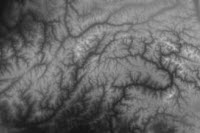

In [11]:
il_item = gis.content.get('58a541efc59545e6b7137f961d7de883')
il_item

In [12]:
il = il_item.layers[0]

In [13]:
for rf in il.properties.rasterFunctionInfos:
    print(rf['name'])

None
Aspect
Aspect_Map
Grayscale_Hillshade
Multi-Directional_Hillshade
Ellipsoidal_Height
Slope_Degrees
Slope_Degrees_Map
Slope_Percent
Elevation_Tinted_Hillshade
None


In [14]:
tinted_il = apply(il, 'Elevation_Tinted_Hillshade')
type(tinted_il)

arcgis.raster._layer.ImageryLayer

In [15]:
from arcgis.raster import hillshade, stretch
hill_il = hillshade(il)

In [16]:
hill_stretch_il = stretch(hill_il)

In [71]:
map1.add_layer(tinted_il)

In [26]:
map1.add_layer(hill_stretch_il)

## Add geocoded results 
(In memory feature collections)

In [11]:
from arcgis.geocoding import geocode

In [12]:
sps_extent = geocode('Mableton, GA')[0]['extent']
groceries = geocode('grocery', search_extent=sps_extent, 
                    as_featureset=True)
restaurants = geocode('restaurant', search_extent=sps_extent, 
                    as_featureset=True)



In [13]:
map1.draw(groceries)

In [23]:
groceries.features[0]

{"geometry": {"x": -84.601530066651, "y": 33.77401004832919, "spatialReference": {"wkid": 4326, "latestWkid": 4326}}, "attributes": {"Loc_name": "World", "Status": "T", "Score": 100, "Match_addr": "Walmart", "LongLabel": "Walmart, 1100 Thornton Rd, Lithia Springs, GA, 30122, USA", "ShortLabel": "Walmart", "Addr_type": "POI", "Type": "Grocery", "PlaceName": "Walmart", "Place_addr": "1100 Thornton Rd, Lithia Springs, Georgia, 30122", "Phone": "(770) 819-1123", "URL": "", "Rank": 19, "AddBldg": "", "AddNum": "1100", "AddNumFrom": "", "AddNumTo": "", "AddRange": "", "Side": "R", "StPreDir": "", "StPreType": "", "StName": "Thornton", "StType": "Rd", "StDir": "", "BldgType": "", "BldgName": "", "LevelType": "", "LevelName": "", "UnitType": "", "UnitName": "", "SubAddr": "", "StAddr": "1100 Thornton Rd", "Block": "", "Sector": "", "Nbrhd": "", "District": "", "City": "Lithia Springs", "MetroArea": "Atlanta Metro Area", "Subregion": "Douglas", "Region": "Georgia", "RegionAbbr": "GA", "Territor

In [83]:
groceries_fc = FeatureCollection({'featureSet':groceries.to_dict()})

In [82]:
groceries_fc.properties['featureSet']

KeyError: 'featureSet'

In [84]:
gfset = groceries_fc.query()
type(gfset)

arcgis.features.feature.FeatureSet

In [25]:
groceries.sdf.shape

(20, 59)

In [26]:
restaurants.sdf.shape

(20, 59)

In [86]:
map_fc1 = gis.map("Mableton, GA")
map_fc1

In [89]:
map_fc1.add_layer(groceries_fc, { "renderer":"HeatMapRenderer"})

TypeError: unhashable type: 'slice'

In [88]:
# map1.draw(groceries)
map_fc1.draw(groceries)

In [49]:
map_fc1.draw(restaurants)

In [22]:
len(map_fc1._webmap.layers)

1

In [44]:
map_fc1.add_layer(flc_item)

In [33]:
map_fc1.clear_graphics()

In [45]:
for l in map_fc1._widget_layer_list:
    print(type(l))

<class 'arcgis.gis.Item'>


<Item title:"Census Blocks 2010 (with 2017 and 2022 Data)" type:Feature Layer Collection owner:JohnsCreekGA>
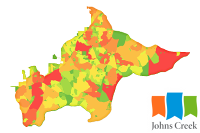

{"features": [{"geometry": {"x": -84.62208994388052, "y": 33.789809963356355, "spatialReference": {"wkid": 4326, "latestWkid": 4326}}, "attributes": {"Loc_name": "World", "Status": "T", "Score": 100, "Match_addr": "Krystal", "LongLabel": "Krystal, 550 Maxham Rd, Austell, GA, 30168, USA", "ShortLabel": "Krystal", "Addr_type": "POI", "Type": "Burgers", "PlaceName": "Krystal", "Place_addr": "550 Maxham Rd, Austell, Georgia, 30168", "Phone": "(770) 948-9485", "URL": "", "Rank": 19, "AddBldg": "", "AddNum": "550", "AddNumFrom": "", "AddNumTo": "", "AddRange": "", "Side": "R", "StPreDir": "", "StPreType": "", "StName": "Maxham", "StType": "Rd", "StDir": "", "BldgType": "", "BldgName": "", "LevelType": "", "LevelName": "", "UnitType": "", "UnitName": "", "SubAddr": "", "StAddr": "550 Maxham Rd", "Block": "", "Sector": "", "Nbrhd": "", "District": "", "City": "Austell", "MetroArea": "Atlanta Metro Area", "Subregion": "Douglas", "Region": "Georgia", "RegionAbbr": "GA", "Territory": "", "Zone": 

In [54]:
from IPython.display import display
for i in map_fc1._widget_layer_list:
    display(i)

In [51]:
groceries in map_fc1._widget_layer_list

False

### Add feature collection items

In [3]:
fc_sr = gis.content.search("","Feature Collection", outside_org=True)
fc_sr

[<Item title:"SEPTA Rail Service" type:Feature Collection owner:magyar04>,
 <Item title:"Federally-Recognized Tribes" type:Feature Collection owner:OpenMaps@SocialSecurity.gov>,
 <Item title:"Driftless_area" type:Feature Collection owner:dornakl>,
 <Item title:"Idleb,Aleppo" type:Feature Collection owner:Waelkhdr>,
 <Item title:"Electricity Transmission Lines (kilovolts)" type:Feature Collection owner:walsubayee@atlasgis.net>,
 <Item title:"sun.Ainu1 (toono, tokap, sirpeker) 0913" type:Feature Collection owner:fukazawa_m>,
 <Item title:"Situación de los derechos de los trabajadores, 2010" type:Feature Collection owner:jvelilla1>,
 <Item title:"zoni_ogr" type:Feature Collection owner:mellowalker>,
 <Item title:"watersheds of Juneau, Alaska" type:Feature Collection owner:rcarstensen2>,
 <Item title:"Top50Breweries" type:Feature Collection owner:gletham>]

<Item title:"SEPTA Rail Service" type:Feature Collection owner:magyar04>
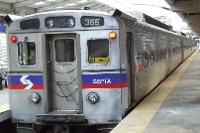

In [4]:
fc1_item = fc_sr[0]
fc1_item

In [5]:
fc1_item.layers

[<FeatureCollection>,
 <FeatureCollection>,
 <FeatureCollection>,
 <FeatureCollection>,
 <FeatureCollection>,
 <FeatureCollection>]

In [6]:
fc1 = fc1_item.layers[0]
fc1

<FeatureCollection>

In [7]:
philly_map = gis.map("Philadelphia, PA")
philly_map

In [8]:
philly_map.add_layer(fc1)

In [9]:
philly_map.layers

[<FeatureCollection>]

In [64]:
philly_map.remove_layers()

In [59]:
philly_map._js_layer_list

'[]'

In [ ]:
philly_map._webmap.layers

In [11]:
philly_map.save('Philly map with fc item with popups','popup trials',['automation'])

<Item title:"Philly map with fc item with popups" type:Web Map owner:arcgis_python>

## Set custom basemaps

In [ ]:
map2 = gis.map('Duluth, GA')
map2

In [ ]:
map2.add_layer(flc_item)

In [ ]:
map2.basemap = 'dark-gray-vector'

In [ ]:
map2._js_basemap

In [ ]:
wm3 = map2.save("duluth basemaps", "duluth basemaps", ['automation'])
wm3

## Add different renderers
### Heatmap renderer

In [ ]:
flayer2 = FeatureLayer("http://services1.arcgis.com/hLJbHVT9ZrDIzK0I/arcgis/rest/services/EQMagGt4/FeatureServer/0")
flayer2

In [ ]:
map3 = gis.map('Santa Clarita, CA', zoomlevel=9)
map3

In [ ]:
map3.add_layer(flayer2,{"renderer":"HeatmapRenderer","opacity":0.75})

In [ ]:
d1 = json.loads(map3._js_layerList)
d1[0].keys()

In [ ]:
d1[0]['rendererType']

In [ ]:
d1[0]['renderer'].keys()

In [ ]:
import json
for i in map3._js_layerList:
    parsed_i = json.loads(i)
    print(parsed_i['id'] + " " + parsed_i['url'])

In [ ]:
map3._webmap.layers

In [ ]:
map3._js_basemap

### Class sized renderer

In [ ]:
flayer2 = FeatureLayer("http://services1.arcgis.com/hLJbHVT9ZrDIzK0I/arcgis/rest/services/EQMagGt4/FeatureServer/0")
flayer2

In [ ]:
flayer2.query().sdf.head()

In [ ]:
map5 = gis.map("Santa Clarita, CA", zoomlevel=9)
map5

In [ ]:
map5.add_layer(flayer2, {'renderer':'ClassedSizeRenderer', 'field_name':'MAG'})

In [ ]:
d1 = json.loads(map5._js_layerList)
d1[0]['renderer'].keys()

In [ ]:
d1

### Classed color renderer

In [ ]:
flayer2 = FeatureLayer("http://services1.arcgis.com/hLJbHVT9ZrDIzK0I/arcgis/rest/services/EQMagGt4/FeatureServer/0")
flayer2

In [ ]:
map6 = gis.map('Santa Clarita, CA', zoomlevel=9)
map6

In [ ]:
map6.add_layer(flayer2, {'renderer':'ClassedColorRenderer', 'field_name':'MAG'})

In [ ]:
d2 = json.loads(map6._js_layerList)
d2

## Remove layers - individual layer

In [45]:
map4 = gis.map("Duluth, GA", zoomlevel=10)
map4

In [49]:
map4.add_layer(flc_item.layers[0])

In [51]:
map4.add_layer(mil.layers)

Add geocoded results (graphics layers)

In [50]:
map4.draw(restaurants)

In [52]:
grocery_symbol = {"angle":0,"xoffset":0,"yoffset":0,"type":"esriPMS","url":"http://static.arcgis.com/images/Symbols/PeoplePlaces/Dining.png","contentType":"image/png","width":12,"height":12}
map4.draw(groceries, symbol=grocery_symbol)

In [56]:
jslist = json.loads(map4._js_layer_list)
print(len(jslist))
for l in jslist:
    print(l['url'])

5
https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0?token=_xjfhat5bKhJE7tRMk4AheaONVxYovstXAedHTObU9mLX0JT0Y9nIcmupJf6hN7D3u2nMoj7L_L9Ijh2w_d9sSZp1gAM7-HUJDZWRdppDAq2xd49u9BeMlomRGSYXYmhxl1O3ZIZDaxyDF15VvPGttCq6OkSmWiQudY6kJj6XZY.
https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/0
https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/1
https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2
https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/3


In [53]:
len(map4.layers)

5

In [59]:
map4.layers

[<FeatureLayer url:"https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/0">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/1">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/2">,
 <FeatureLayer url:"https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/3">]

In [54]:
for l in map4.layers:
    print(l.properties.name)

CensusBlocks2017_withData
Census Block Points
Census Block Group
Detailed Counties
states


In [55]:
len(map4._widget_graphics_list)

2

In [57]:
len(map4._webmap.layers)

7

In [36]:
map4.remove_layers(layers=[map4.layers[-2]])

True

In [37]:
print(len(map4.layers))
print(len(map4._widget_graphics_list))
print(len(map4._webmap.layers))

4
3
7


In [58]:
for l in map4._webmap.layers:
    print(l['title'])

CensusBlocks2017_withData
Notebook sketch layer
Census Block Points
Census Block Group
Detailed Counties
states
Notebook sketch layer


In [62]:
map4._webmap._webmapdict['operationalLayers'][-1].keys()

dict_keys(['title', 'opacity', 'visibility', 'id', 'layerDefinition', 'layerType', 'featureCollection'])

In [68]:
map4._webmap._webmapdict['operationalLayers'][-1]['featureCollection']['layers'][0]['layerDefinition']

{'drawingInfo': {'renderer': {'symbol': {'angle': 0,
    'contentType': 'image/png',
    'height': 12,
    'type': 'esriPMS',
    'url': 'http://static.arcgis.com/images/Symbols/PeoplePlaces/Dining.png',
    'width': 12,
    'xoffset': 0,
    'yoffset': 0},
   'type': 'simple'}},
 'fields': ['Loc_name',
  'Status',
  'Score',
  'Match_addr',
  'LongLabel',
  'ShortLabel',
  'Addr_type',
  'Type',
  'PlaceName',
  'Place_addr',
  'Phone',
  'URL',
  'Rank',
  'AddBldg',
  'AddNum',
  'AddNumFrom',
  'AddNumTo',
  'AddRange',
  'Side',
  'StPreDir',
  'StPreType',
  'StName',
  'StType',
  'StDir',
  'BldgType',
  'BldgName',
  'LevelType',
  'LevelName',
  'UnitType',
  'UnitName',
  'SubAddr',
  'StAddr',
  'Block',
  'Sector',
  'Nbrhd',
  'District',
  'City',
  'MetroArea',
  'Subregion',
  'Region',
  'RegionAbbr',
  'Territory',
  'Zone',
  'Postal',
  'PostalExt',
  'Country',
  'LangCode',
  'Distance',
  'X',
  'Y',
  'DisplayX',
  'DisplayY',
  'Xmin',
  'Xmax',
  'Ymin',
  'Y

In [68]:
map4.clear_graphics()

KeyError: 'operationalLayers'

In [69]:
print(len(map4.layers))
print(len(map4._widget_graphics_list))
print(len(map4._webmap.layers))

0
5
0


In [34]:
map4._webmap.layers

[{
   "title": "CensusBlocks2017_withData",
   "opacity": 1,
   "visibility": true,
   "id": "38d6cf95-9171-4552-922b-5e3668f4d0d7",
   "layerDefinition": {
     "definitionExpression": null
   },
   "layerType": "ArcGISFeatureLayer",
   "itemId": "8d29d4a521f34ebba40dd918ac8322c3",
   "url": "https://services1.arcgis.com/bqfNVPUK3HOnCFmA/arcgis/rest/services/Census_Blocks_2010_(with_2017_and_2022_Data)/FeatureServer/0"
 }, {
   "title": "Census Block Points",
   "opacity": 1,
   "visibility": true,
   "id": "b3c191fa-f8e2-4862-b33c-fa84492bfc88",
   "layerDefinition": {
     "definitionExpression": null
   },
   "layerType": "ArcGISFeatureLayer",
   "url": "https://sampleserver6.arcgisonline.com/arcgis/rest/services/Census/MapServer/0"
 }, {
   "title": "Census Block Group",
   "opacity": 1,
   "visibility": true,
   "id": "e2971c35-5062-43ef-91ca-cac8ab198d0e",
   "layerDefinition": {
     "definitionExpression": null
   },
   "layerType": "ArcGISFeatureLayer",
   "url": "https://sam

In [ ]:
# check which layer was removed from webmap
map4._webmap.layers
# map4.layers

In [ ]:
# now add a layer back and check if all works fine
map4.add_layer(flc_item.layers[0])

## Remove layers - remove all layers - old funcitonality

In [ ]:
map5 = gis.map('Duluth, GA', zoomlevel=10)
map5streets-night-vector

In [ ]:
map5.add_layer(flc_item.layers[0])
map5.add_layer(mil.layers)

In [ ]:
map5.remove_layers()

In [ ]:
map5.layers

### remove layers - bad input

In [ ]:
map6 = gis.map("Duluth, GA", zoomlevel=10)
map6

In [ ]:
map6.add_layer(flc_item)

In [ ]:
map6.add_layer(mil.layers)

In [ ]:
for l in map6.layers:
    map6.remove_layers(l)

In [ ]:
map6._webmap._webmapdict

In [ ]:
map6.remove_layers({'some':'bad dict'})

In [ ]:
for l in map6._webmap.layers:
    map6._webmap.remove_layer(l)

In [ ]:
map6._webmap.layers

## Save widget as a web map
Saving should persist the following
 - extent of widget = extent of web map item
 - layers added = operational layers of web map
 - basemap of widget = basemap of web map (including vector basemap)

In [ ]:
for ol in map1._webmap.layers:
    print(ol.title + "\t" + ol.layerType)

In [ ]:
wmitem = map1.save(title='GA dark gray vector basemap',snippet='automation',tags=['automation'])
wmitem

In [ ]:
wmitem.extent

## Embed webmap

In [59]:
display(HTML('<style>.embed-container {position: relative; padding-bottom: 80%; height: 0; max-width: 100%;} .embed-container iframe, .embed-container object, .embed-container iframe{position: absolute; top: 0; left: 0; width: 100%; height: 100%;} small{position: absolute; z-index: 40; bottom: 0; margin-bottom: -15px;}</style><div class="embed-container"><small><a href="//geosaurus.maps.arcgis.com/apps/Embed/index.html?webmap=4dfc8e2b527d409cbd8446f75e4c06ea&amp;extent=-84.4138,33.9026,-83.9181,34.1444&amp;home=true&amp;zoom=true&amp;scale=true&amp;legend=true&amp;disable_scroll=true&amp;theme=light" style="color:#0000FF;text-align:left" target="_blank">View larger map</a></small><br><iframe width="500" height="400" frameborder="0" scrolling="no" marginheight="0" marginwidth="0" title="Duluth blue polygons2" src="//geosaurus.maps.arcgis.com/apps/Embed/index.html?webmap=4dfc8e2b527d409cbd8446f75e4c06ea&amp;extent=-84.4138,33.9026,-83.9181,34.1444&amp;home=true&amp;zoom=true&amp;previewImage=false&amp;scale=true&amp;legend=true&amp;disable_scroll=true&amp;theme=light"></iframe></div>'))

In [60]:
from IPython.core.display import display, HTML
display(HTML('<iframe width="100%" height="800px" src="https://arcgis-content.maps.arcgis.com/apps/Cascade/index.html?appid=4f72ccefe3444314830c821b7d42c723" frameborder="0" scrolling="yes"></iframe>'))